In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.pyplot as plt
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import pyarrow as pa
import ast

THRESHOLD_TIMESTAMPS = 5

In [3]:
df_merged = dd.read_parquet("merged_dataset.parquet")
print(len(df_merged))

22298361


In [4]:

df_merged["page_visit_timestamp"].head().apply(type)

client_id
0    <class 'numpy.ndarray'>
1    <class 'numpy.ndarray'>
2    <class 'numpy.ndarray'>
4    <class 'numpy.ndarray'>
5    <class 'numpy.ndarray'>
Name: page_visit_timestamp, dtype: object

In [5]:
list_cols_data_set = ["page_visit_timestamp", "add_to_cart_timestamp", "product_buy_timestamp",
                      "remove_from_cart_timestamp", "search_query_timestamp"] 

In [6]:
df_merged[list_cols_data_set] = df_merged[list_cols_data_set].map_partitions(
    lambda pdf: pdf.apply(
        lambda col: col.apply(
            lambda x: x.tolist() if isinstance(x, np.ndarray) else ([] if x is None else x)
        )
    )
)


In [ ]:
df_merged["Total_timestamps"] = df_merged[list_cols_data_set].map_partitions(
    lambda pdf: pdf.apply(
        lambda row: sum(len(x) if isinstance(x, list) else 0 for x in row),
        axis=1
    )
)


In [8]:
df_merged["Total_timestamps"].tail()

client_id
23929214     2
23929215     1
23929216     3
23929217     3
23929218    75
Name: Total_timestamps, dtype: int64

In [9]:
with ProgressBar():
    list_ts = df_merged["Total_timestamps"].compute().tolist()

[#############################           ] | 72% Completed | 225.76 s

IOStream.flush timed out


[########################################] | 100% Completed | 495.24 s


In [10]:
print(np.median(list_ts))
print(len(list_ts))

2.0
22298361


In [9]:
with ProgressBar():
    user_with_few_events = (df_merged["Total_timestamps"].isin([1,2,3,4,5])).sum().compute()
    total_users = df_merged.shape[0].compute()
    percent_users_few_events = (user_with_few_events / total_users) * 100
    
    print("User Activity")
    print(f"Total users: {total_users}")
    print(f"Users with 1–5 events: {user_with_few_events}")
    print(f"Percentage of users with 1–5 events: {percent_users_few_events:.2f}%")
    

[########################################] | 100% Completed | 470.09 s
[########################################] | 100% Completed | 103.63 ms
User Activity
Total users: 22298361
Users with 1–5 events: 16101834
Percentage of users with 1–5 events: 72.21%


In [11]:
with ProgressBar():
    passed_lenghts_timestamps = df_merged[df_merged["Total_timestamps"] > THRESHOLD_TIMESTAMPS]["Total_timestamps"].compute()
    print(f"Total after the threshold {len(passed_lenghts_timestamps)}")
    print(f"Median after the threshold {np.median(passed_lenghts_timestamps)}")


[########################################] | 100% Completed | 456.20 s
Total after the threshold 6196527
Median after the threshold 13.0


In [12]:
total_sessions = len(df_merged)
kept_sessions = len(passed_lenghts_timestamps)
lost_sessions = total_sessions - kept_sessions

percent_lost = (lost_sessions / total_sessions) * 100
print(f"{percent_lost:.2f}%")

72.21%


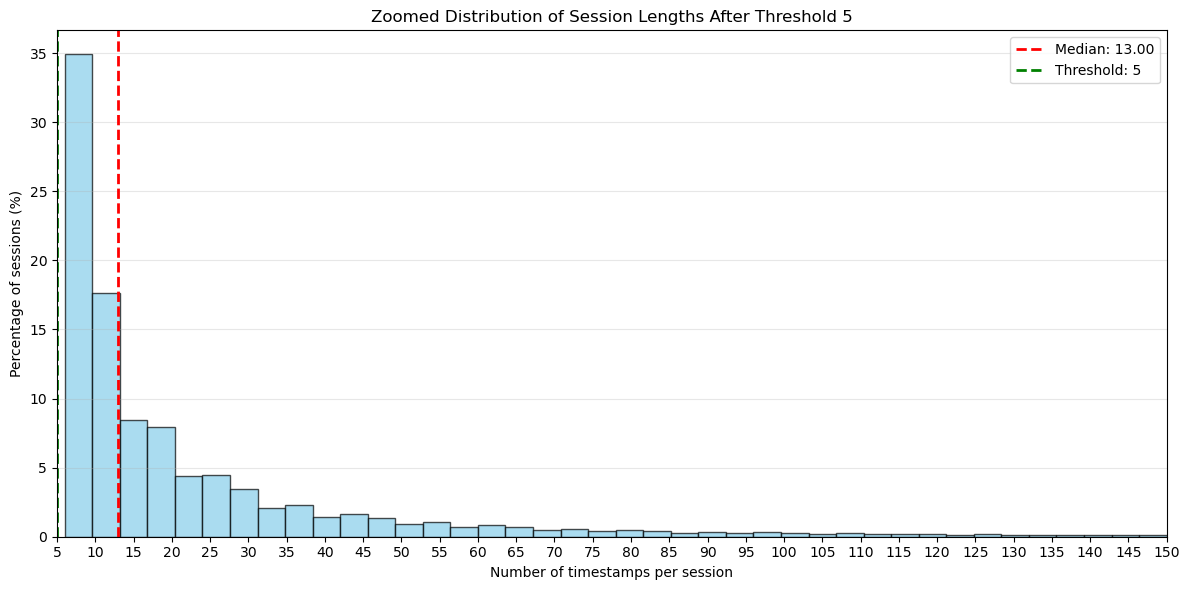

In [ ]:
"""
Histograms 
"""


max_range = 150
filtered_for_plot = passed_lenghts_timestamps[passed_lenghts_timestamps <= max_range]

plt.figure(figsize=(12, 6))

counts, bins = np.histogram(filtered_for_plot, bins=40)
bin_width = bins[1] - bins[0]
counts_percentage = (counts / counts.sum()) * 100

plt.bar(
    bins[:-1],
    counts_percentage,
    width=bin_width,
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    align="edge"
)


plt.axvline(
    np.median(passed_lenghts_timestamps),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median: {np.median(passed_lenghts_timestamps):.2f}"
)

plt.axvline(
    THRESHOLD_TIMESTAMPS,
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Threshold: {THRESHOLD_TIMESTAMPS}"
)

plt.xlim(THRESHOLD_TIMESTAMPS, max_range)

plt.xticks(list(range(THRESHOLD_TIMESTAMPS, max_range+1, 5)))

plt.title(f"Zoomed Distribution of Session Lengths After Threshold {THRESHOLD_TIMESTAMPS}")
plt.xlabel("Number of timestamps per session")
plt.ylabel("Percentage of sessions (%)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
